
**Multi-Label Chest X-Ray Disease Classification Dataset:** NIH ChestX-ray14 (subset — 8 disease labels) Models: ResNet50, EfficientNetB0, VGG16, InceptionV3 Regularization: Dropout, Early Stopping, Weight Decay (L2  group member : kirtikour ,ghulam qadir ,qurban ali

## 📦 Section 1: Install & Import Libraries

In [1]:
# Run this on Kaggle — most packages are pre-installed
!pip install -q grad-cam torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 97.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchmetrics.classification import MultilabelAUROC, MultilabelF1Score

from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Using device: cuda
GPU: Tesla T4


## 📂 Section 2: Dataset Setup

**How to get the dataset on Kaggle:**
1. Go to: https://www.kaggle.com/datasets/nih-chest-xrays/data
2. Add it to your Kaggle notebook via **+ Add Data**
3. The path will be `/kaggle/input/data/`

In [33]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────

# NEW
DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
# IMG_DIR is no longer needed — delete it

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR         = 1e-4
WEIGHT_DECAY = 1e-4   # L2 Regularization
NUM_WORKERS  = 2
NUM_SAMPLES  = 6000   # Subset for feasibility — well above 5000 minimum

LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion',
    'Infiltration', 'Mass', 'Nodule',
    'Pneumonia', 'Pneumothorax'
]
NUM_CLASSES = len(LABELS)
print(f'Classifying {NUM_CLASSES} diseases: {LABELS}')

Classifying 8 diseases: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']


In [34]:
# ─── LOAD & PARSE CSV ─────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f'Total records in CSV: {len(df)}')
print(df[['Image Index', 'Finding Labels']].head())

Total records in CSV: 112120
        Image Index          Finding Labels
0  00000001_000.png            Cardiomegaly
1  00000001_001.png  Cardiomegaly|Emphysema
2  00000001_002.png   Cardiomegaly|Effusion
3  00000002_000.png              No Finding
4  00000003_000.png                  Hernia


In [35]:
# ─── CREATE MULTI-HOT LABEL COLUMNS ──────────────────────────────────────────
for label in LABELS:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# Keep only images that have at least one of our 8 labels OR are 'No Finding'
label_mask = df[LABELS].sum(axis=1) > 0
df_labeled = df[label_mask].copy()

# Sample for manageable training
df_sample = df_labeled.sample(n=min(NUM_SAMPLES, len(df_labeled)), random_state=SEED).reset_index(drop=True)
print(f'Sampled {len(df_sample)} images with at least one disease label')

# Label distribution
label_counts = df_sample[LABELS].sum().sort_values(ascending=False)
print('\nLabel distribution:')
print(label_counts)

Sampled 6000 images with at least one disease label

Label distribution:
Infiltration    2554
Effusion        1743
Atelectasis     1493
Nodule           825
Mass             735
Pneumothorax     659
Cardiomegaly     354
Pneumonia        175
dtype: int64


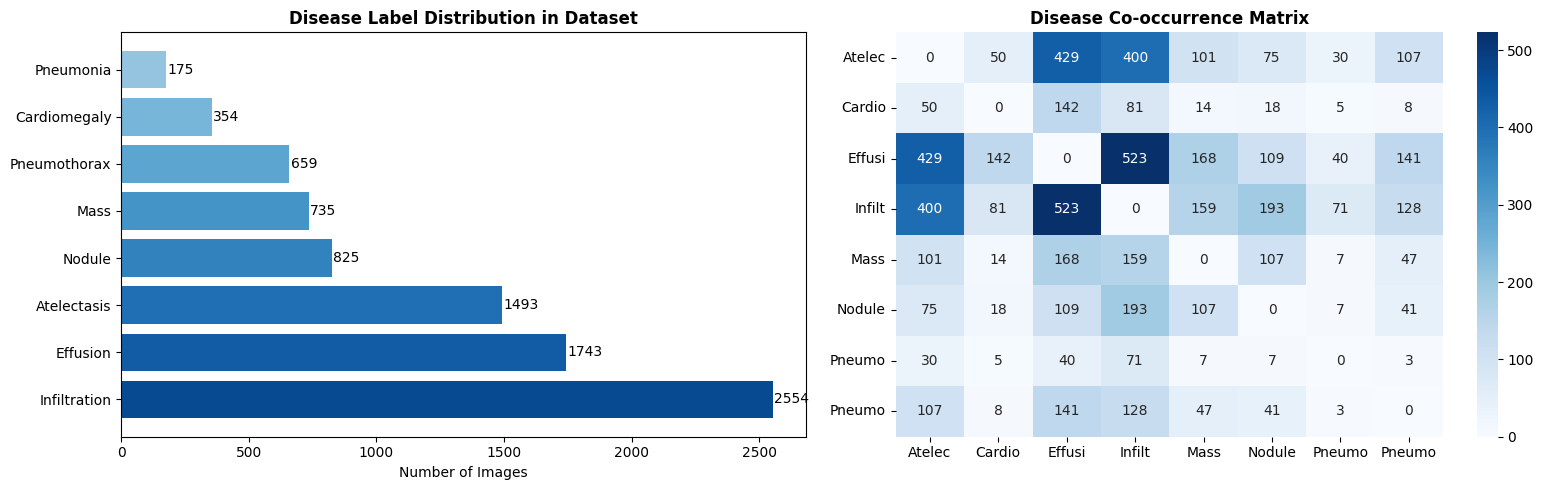

In [36]:
# ─── VISUALIZE LABEL DISTRIBUTION ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = plt.cm.Blues(np.linspace(0.4, 0.9, NUM_CLASSES))
axes[0].barh(label_counts.index, label_counts.values, color=colors[::-1])
axes[0].set_xlabel('Number of Images')
axes[0].set_title('Disease Label Distribution in Dataset', fontweight='bold')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Co-occurrence heatmap
cooc = df_sample[LABELS].T.dot(df_sample[LABELS])
np.fill_diagonal(cooc.values, 0)
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=[l[:6] for l in LABELS],
            yticklabels=[l[:6] for l in LABELS])
axes[1].set_title('Disease Co-occurrence Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔀 Section 3: Train/Val/Test Split & Dataset Class

In [37]:
# ─── SPLIT ────────────────────────────────────────────────────────────────────
train_df, temp_df = train_test_split(df_sample, test_size=0.2, random_state=SEED)
val_df,   test_df = train_test_split(temp_df,   test_size=0.5, random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 4800 | Val: 600 | Test: 600


In [38]:
# ─── TRANSFORMS ───────────────────────────────────────────────────────────────
# Training: heavy augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/Test: no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [51]:
# ─── DATASET CLASS ────────────────────────────────────────────────────────────
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe
        self.img_dir   = img_dir
        self.transform = transform
        self.labels    = LABELS

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = IMAGE_MAP[row['Image Index']]   # ← THIS LINE is the fix

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        label = torch.FloatTensor(row[self.labels].values.astype(float))
        return image, label


# Create datasets
train_dataset = ChestXRayDataset(train_df, IMG_DIR, train_transforms)
val_dataset   = ChestXRayDataset(val_df,   IMG_DIR, val_transforms)
test_dataset  = ChestXRayDataset(test_df,  IMG_DIR, val_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 150 | Val batches: 19 | Test batches: 19


In [32]:
import os
# Find the actual mounted path
for item in os.listdir('/kaggle/input/datasets/organizations/nih-chest-xrays/data'):
    print(item)

images_003
images_012
LOG_CHESTXRAY.pdf
README_CHESTXRAY.pdf
BBox_List_2017.csv
images_009
images_008
images_007
test_list.txt
images_010
ARXIV_V5_CHESTXRAY.pdf
images_002
images_011
Data_Entry_2017.csv
images_001
train_val_list.txt
images_005
FAQ_CHESTXRAY.pdf
images_004
images_006


In [52]:
def build_image_index(data_dir):
    image_map = {}
    for folder in sorted(os.listdir(data_dir)):
        img_folder = os.path.join(data_dir, folder, 'images')
        if os.path.exists(img_folder):
            for fname in os.listdir(img_folder):
                image_map[fname] = os.path.join(img_folder, fname)
    return image_map

IMAGE_MAP = build_image_index(DATA_DIR)
print(f'Total images indexed: {len(IMAGE_MAP)}')

Total images indexed: 112120


In [53]:
# Quick check — should print a valid path
sample_key = list(IMAGE_MAP.keys())[0]
print(sample_key, '→', IMAGE_MAP[sample_key])

00000502_003.png → /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000502_003.png


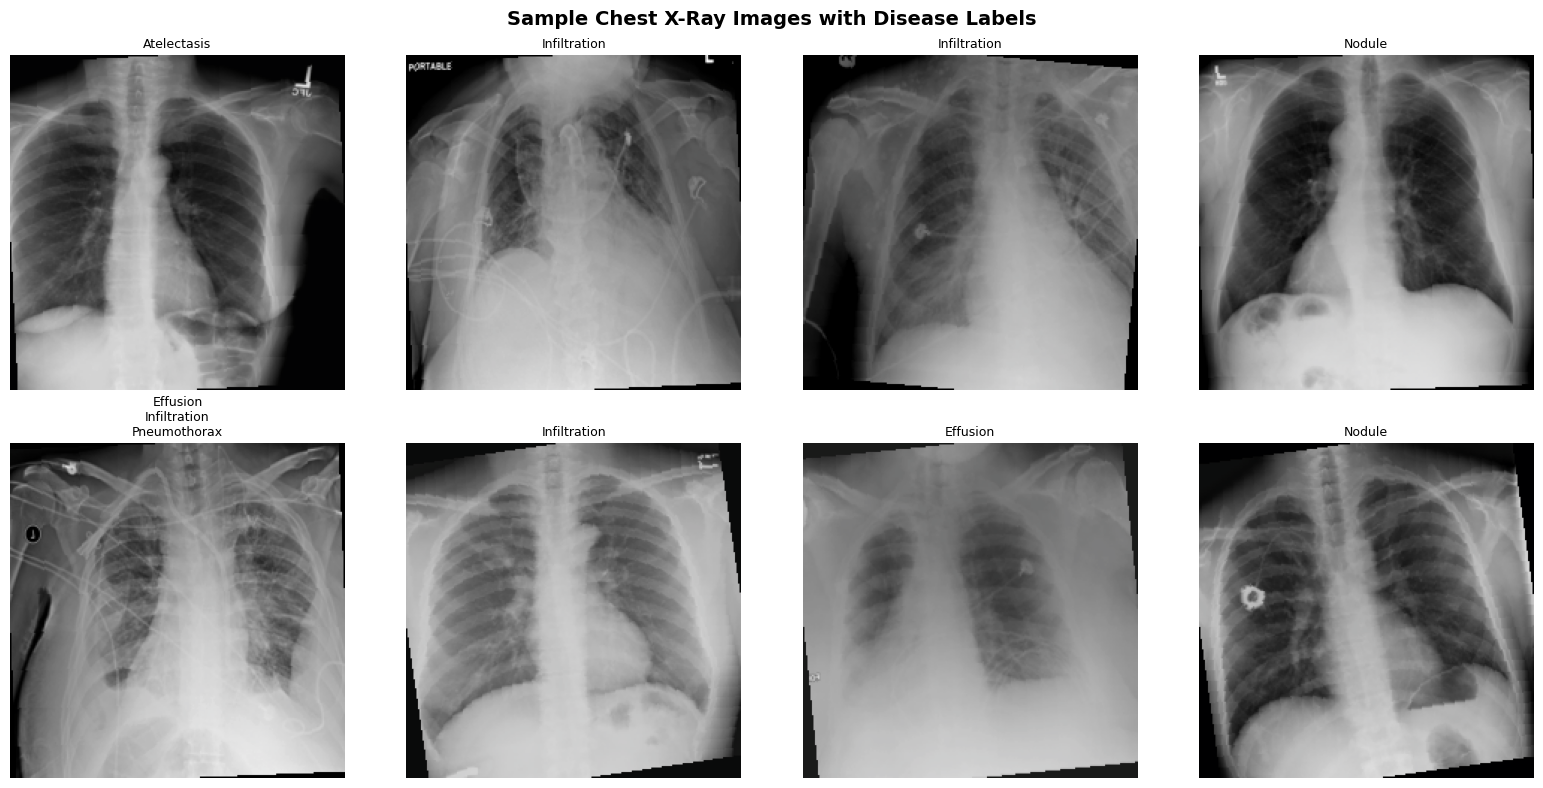

In [54]:
# ─── VISUALIZE SAMPLE IMAGES ──────────────────────────────────────────────────
def show_sample_images(dataset, n=8):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for i in range(n):
        img, label = dataset[i]
        img_np = img.permute(1, 2, 0).numpy()
        img_np = std * img_np + mean  # denormalize
        img_np = np.clip(img_np, 0, 1)

        axes[i].imshow(img_np, cmap='gray')
        active = [LABELS[j] for j in range(NUM_CLASSES) if label[j] == 1]
        axes[i].set_title('\n'.join(active) if active else 'No Finding', fontsize=9)
        axes[i].axis('off')

    plt.suptitle('Sample Chest X-Ray Images with Disease Labels', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_images(train_dataset)

## 🧠 Section 4: Model Definitions
All 4 models use **ImageNet pre-trained weights** with a custom classifier head.  
Regularization applied: **Dropout**, **Weight Decay (L2)** via optimizer, **Early Stopping** during training.

In [55]:
def build_model(model_name, num_classes=NUM_CLASSES, dropout_rate=0.5):
    """
    Build a pre-trained CNN model with a custom multi-label classification head.
    Dropout is applied in the classifier head for regularization.
    """
    if model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V2')
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate * 0.5),
            nn.Linear(512, num_classes)
        )

    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate * 0.5),
            nn.Linear(512, num_classes)
        )

    elif model_name == 'vgg16':
        model = models.vgg16(weights='IMAGENET1K_V1')
        in_features = model.classifier[6].in_features
        model.classifier[5] = nn.Dropout(p=dropout_rate)   # replace existing dropout
        model.classifier[6] = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate * 0.5),
            nn.Linear(512, num_classes)
        )

    elif model_name == 'inception_v3':
        model = models.inception_v3(weights='IMAGENET1K_V1', aux_logits=True)
        # Main classifier
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate * 0.5),
            nn.Linear(512, num_classes)
        )
        # Auxiliary classifier
        aux_features = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(aux_features, num_classes)

    else:
        raise ValueError(f'Unknown model: {model_name}')

    return model.to(DEVICE)


# Test build
for name in ['resnet50', 'efficientnet_b0', 'vgg16', 'inception_v3']:
    m = build_model(name)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name:20s} — Trainable params: {params:,}')
    del m

resnet50             — Trainable params: 24,561,224
efficientnet_b0      — Trainable params: 4,667,524
vgg16                — Trainable params: 136,362,312
inception_v3         — Trainable params: 25,402,608


## 🏋️ Section 5: Training Infrastructure

In [56]:
# ─── EARLY STOPPING ───────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Monitors validation loss and stops training when it stops improving.
    Saves the best model weights automatically.
    """
    def __init__(self, patience=5, min_delta=1e-4, path='best_model.pth'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.best_loss  = np.inf
        self.counter    = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

print('EarlyStopping class defined ✓')

EarlyStopping class defined ✓


In [57]:
# ─── TRAINING & VALIDATION FUNCTIONS ──────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, model_name):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, desc='Training', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if model_name == 'inception_v3':
            outputs, aux_outputs = model(imgs)
            loss = criterion(outputs, labels) + 0.4 * criterion(aux_outputs, labels)
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Validating', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(outputs).cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    auc = roc_auc_score(all_labels, all_preds, average='macro')

    return total_loss / len(loader), auc


print('Training functions defined ✓')

Training functions defined ✓


In [59]:
# ─── MAIN TRAINING LOOP ───────────────────────────────────────────────────────
def train_model(model_name, epochs=NUM_EPOCHS, patience=5):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name.upper()}')
    print(f'{"="*60}')

    # Inception needs 299x299
    if model_name == 'inception_v3':
        inc_transform = transforms.Compose([
            transforms.Resize((319, 319)),
            transforms.RandomCrop(299),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        inc_val_transform = transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        _train_ds = ChestXRayDataset(train_df, IMG_DIR, inc_transform)
        _val_ds   = ChestXRayDataset(val_df,   IMG_DIR, inc_val_transform)
        _train_loader = DataLoader(_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
        _val_loader   = DataLoader(_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    else:
        _train_loader, _val_loader = train_loader, val_loader

    model     = build_model(model_name)
    criterion = nn.BCEWithLogitsLoss()                              # Multi-label loss
    optimizer = optim.Adam(model.parameters(), lr=LR,
                           weight_decay=WEIGHT_DECAY)               # L2 regularization
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    early_stopping = EarlyStopping(patience=patience,
                                   path=f'best_{model_name}.pth')

    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, _train_loader, optimizer, criterion, model_name)
        val_loss, val_auc = validate(model, _val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        print(f'Epoch [{epoch:02d}/{epochs}] '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val AUC: {val_auc:.4f} | '
              f'ES Counter: {early_stopping.counter}/{patience}')

        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

    # Load best weights
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    print(f'  Best Val AUC: {max(history["val_auc"]):.4f}')
    return model, history

In [60]:
# ─── TRAIN ALL MODELS ─────────────────────────────────────────────────────────
# NOTE: This will take ~30–60 min on Kaggle P100. Run one at a time if needed.

model_names  = ['resnet50', 'efficientnet_b0', 'vgg16', 'inception_v3']
trained_models   = {}
training_histories = {}

for name in model_names:
    model, history = train_model(name)
    trained_models[name]     = model
    training_histories[name] = history

print('\n✅ All models trained!')


  Training: RESNET50


Epoch [01/20] Train Loss: 0.4358 | Val Loss: 0.3974 | Val AUC: 0.6219 | ES Counter: 0/5


Training:  76%|███████▌  | 114/150 [00:51<00:16,  2.21it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dcbf19c14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child processException ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7dcbf19c14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python

Epoch [02/20] Train Loss: 0.3945 | Val Loss: 0.3843 | Val AUC: 0.6633 | ES Counter: 0/5


Training:  31%|███       | 46/150 [00:20<00:44,  2.36it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dcbf19c14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dcbf19c14e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3

...

Epoch [04/20] Train Loss: 0.4456 | Val Loss: 0.3765 | Val AUC: 0.7293 | ES Counter: 0/5


Epoch [05/20] Train Loss: 0.4050 | Val Loss: 0.3819 | Val AUC: 0.7306 | ES Counter: 1/5


Epoch [06/20] Train Loss: 0.3666 | Val Loss: 0.3901 | Val AUC: 0.7247 | ES Counter: 2/5


Epoch [07/20] Train Loss: 0.3212 | Val Loss: 0.4083 | Val AUC: 0.7212 | ES Counter: 3/5


Epoch [08/20] Train Loss: 0.2501 | Val Loss: 0.4375 | Val AUC: 0.7148 | ES Counter: 4/5
  Early stopping triggered at epoch 8
  Best Val AUC: 0.7306

✅ All models trained!


## 📊 Section 6: Training Curves Visualization

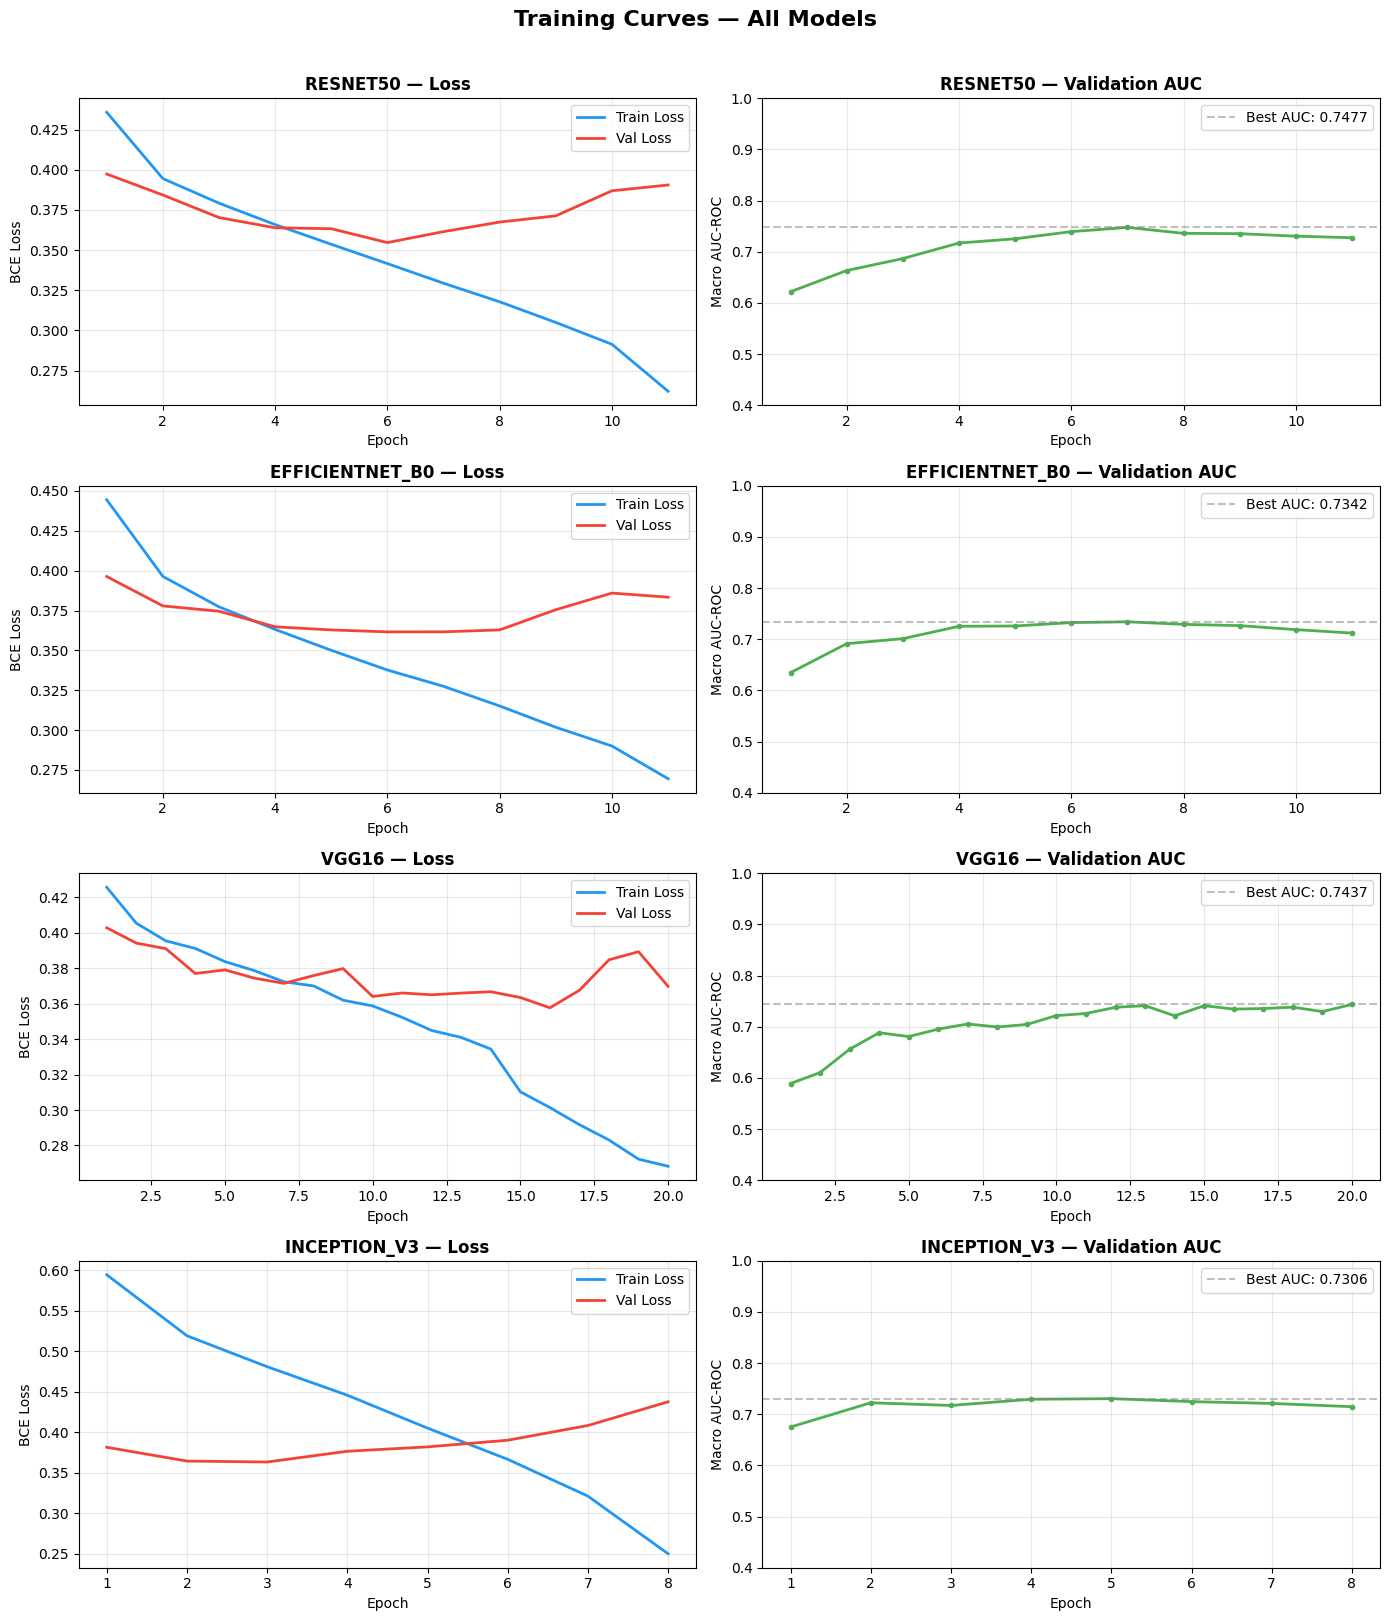

In [61]:
fig, axes = plt.subplots(len(model_names), 2, figsize=(14, 4 * len(model_names)))
colors = {'train_loss': '#2196F3', 'val_loss': '#F44336', 'val_auc': '#4CAF50'}

for i, name in enumerate(model_names):
    h = training_histories[name]
    epochs = range(1, len(h['train_loss']) + 1)

    # Loss curves
    axes[i, 0].plot(epochs, h['train_loss'], color=colors['train_loss'], label='Train Loss', linewidth=2)
    axes[i, 0].plot(epochs, h['val_loss'],   color=colors['val_loss'],   label='Val Loss',   linewidth=2)
    axes[i, 0].set_title(f'{name.upper()} — Loss', fontweight='bold')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('BCE Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    # AUC curve
    axes[i, 1].plot(epochs, h['val_auc'], color=colors['val_auc'], linewidth=2, marker='o', markersize=3)
    axes[i, 1].axhline(y=max(h['val_auc']), color='gray', linestyle='--', alpha=0.5,
                       label=f'Best AUC: {max(h["val_auc"]):.4f}')
    axes[i, 1].set_title(f'{name.upper()} — Validation AUC', fontweight='bold')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Macro AUC-ROC')
    axes[i, 1].legend()
    axes[i, 1].grid(alpha=0.3)
    axes[i, 1].set_ylim([0.4, 1.0])

plt.suptitle('Training Curves — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧪 Section 7: Test Set Evaluation & Comparison

In [62]:
def evaluate_on_test(model, model_name):
    """Full evaluation: per-class AUC, F1, and summary metrics."""
    if model_name == 'inception_v3':
        inc_test_transform = transforms.Compose([
            transforms.Resize((299, 299)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        _test_ds = ChestXRayDataset(test_df, IMG_DIR, inc_test_transform)
        _test_loader = DataLoader(_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    else:
        _test_loader = test_loader

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in _test_loader:
            imgs = imgs.to(DEVICE)
            outputs = torch.sigmoid(model(imgs)).cpu()
            all_preds.append(outputs)
            all_labels.append(labels)

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    binary_preds = (preds >= 0.5).astype(int)

    per_class_auc = roc_auc_score(labels, preds, average=None)
    macro_auc = roc_auc_score(labels, preds, average='macro')
    macro_f1  = f1_score(labels, binary_preds, average='macro', zero_division=0)

    results = {
        'macro_auc': macro_auc,
        'macro_f1':  macro_f1,
        'per_class_auc': dict(zip(LABELS, per_class_auc)),
        'preds': preds,
        'labels': labels
    }
    return results


print('Evaluating all models on test set...')
test_results = {}
for name in model_names:
    print(f'  Evaluating {name}...')
    test_results[name] = evaluate_on_test(trained_models[name], name)
    print(f'    Macro AUC: {test_results[name]["macro_auc"]:.4f} | Macro F1: {test_results[name]["macro_f1"]:.4f}')

print('\n✅ Evaluation complete!')

Evaluating all models on test set...
  Evaluating resnet50...
    Macro AUC: 0.7308 | Macro F1: 0.3138
  Evaluating efficientnet_b0...
    Macro AUC: 0.7400 | Macro F1: 0.2891
  Evaluating vgg16...
    Macro AUC: 0.7352 | Macro F1: 0.3137
  Evaluating inception_v3...
    Macro AUC: 0.7188 | Macro F1: 0.2637

✅ Evaluation complete!


In [63]:
# ─── MODEL COMPARISON TABLE ───────────────────────────────────────────────────
comparison_data = []
for name in model_names:
    r = test_results[name]
    row = {'Model': name.replace('_', ' ').title(),
           'Macro AUC': round(r['macro_auc'], 4),
           'Macro F1':  round(r['macro_f1'],  4)}
    row.update({f'AUC-{l[:6]}': round(v, 3) for l, v in r['per_class_auc'].items()})
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print('\n📊 Model Comparison Table:')
print(comparison_df.to_string())
comparison_df.to_csv('model_comparison.csv')


📊 Model Comparison Table:
                 Macro AUC  Macro F1  AUC-Atelec  AUC-Cardio  AUC-Effusi  AUC-Infilt  AUC-Mass  AUC-Nodule  AUC-Pneumo
Model                                                                                                                 
Resnet50            0.7308    0.3138       0.748       0.829       0.812       0.671     0.695       0.699       0.846
Efficientnet B0     0.7400    0.2891       0.736       0.864       0.815       0.669     0.671       0.731       0.868
Vgg16               0.7352    0.3137       0.723       0.902       0.827       0.658     0.737       0.686       0.821
Inception V3        0.7188    0.2637       0.728       0.841       0.799       0.673     0.725       0.735       0.818


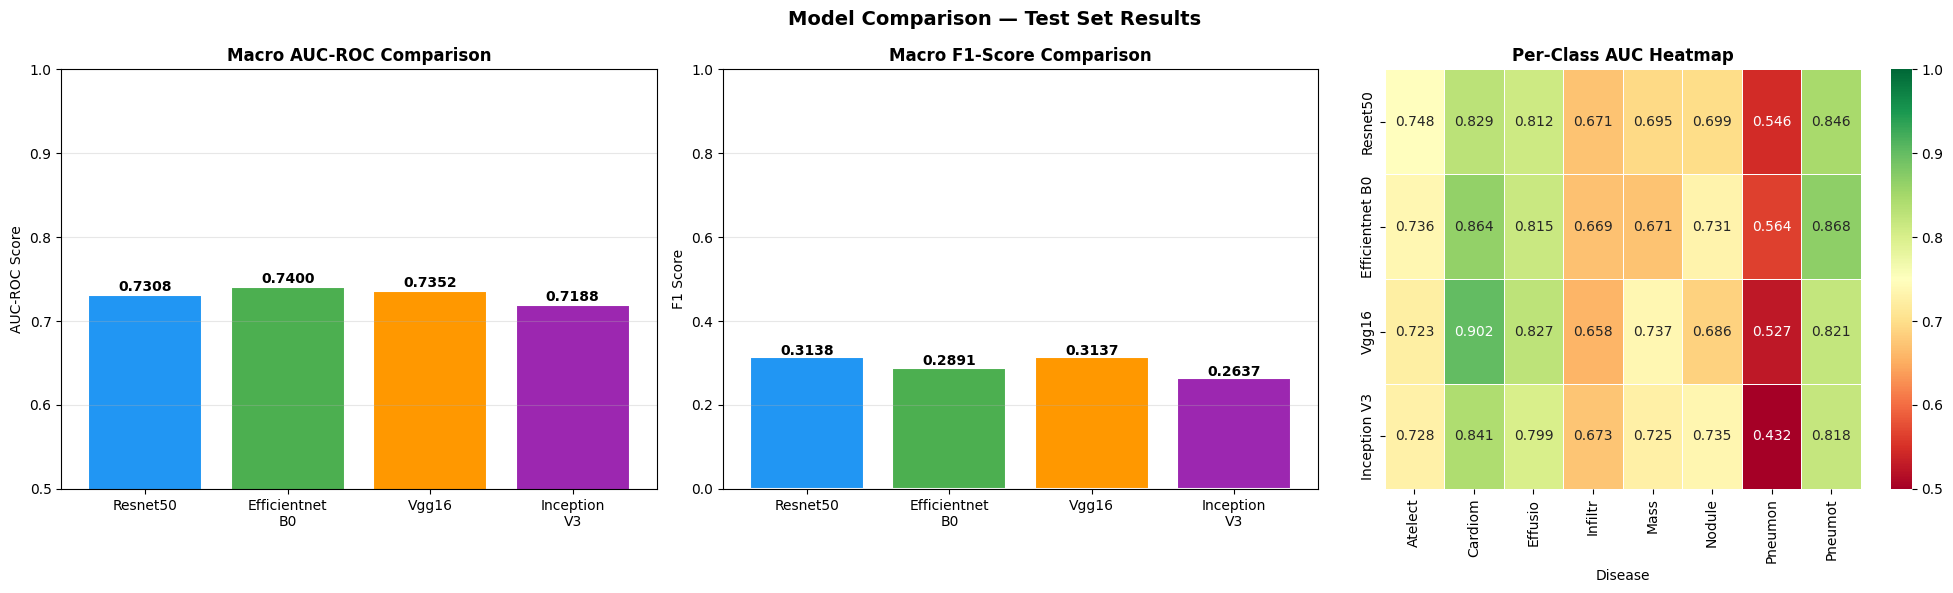

In [64]:
# ─── COMPARISON VISUALIZATIONS ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_display = [n.replace('_', '\n').title() for n in model_names]
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# 1. Macro AUC comparison
aucs = [test_results[n]['macro_auc'] for n in model_names]
bars = axes[0].bar(model_display, aucs, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Macro AUC-ROC Comparison', fontweight='bold', fontsize=12)
axes[0].set_ylabel('AUC-ROC Score')
axes[0].set_ylim([0.5, 1.0])
for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 2. Macro F1 comparison
f1s = [test_results[n]['macro_f1'] for n in model_names]
bars = axes[1].bar(model_display, f1s, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Macro F1-Score Comparison', fontweight='bold', fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim([0, 1.0])
for bar, val in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# 3. Per-class AUC heatmap
per_class = pd.DataFrame(
    {n: test_results[n]['per_class_auc'] for n in model_names}
).T
per_class.index = [n.replace('_', ' ').title() for n in model_names]
sns.heatmap(per_class, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, ax=axes[2], linewidths=0.5,
            xticklabels=[l[:7] for l in LABELS])
axes[2].set_title('Per-Class AUC Heatmap', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Disease')

plt.suptitle('Model Comparison — Test Set Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Section 8: ROC Curves

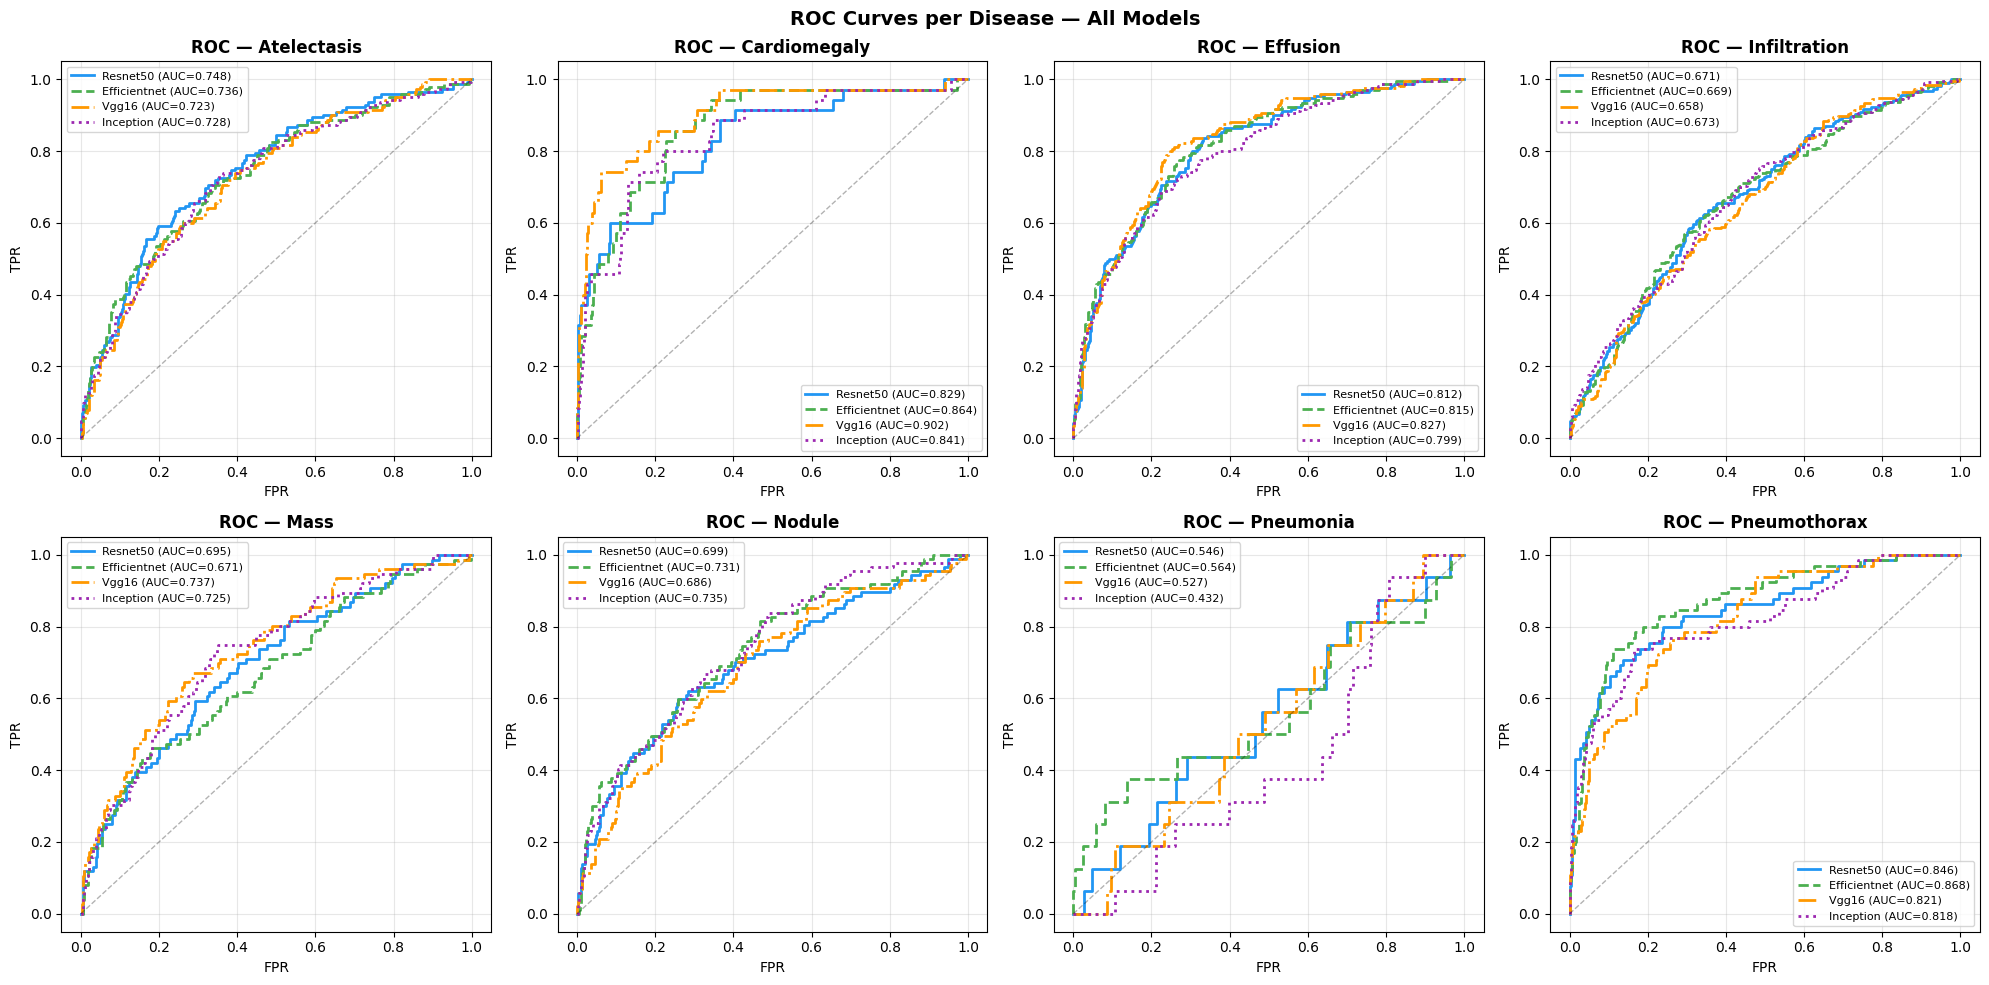

In [65]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
line_styles = ['-', '--', '-.', ':']

for i, label in enumerate(LABELS):
    for j, (name, style) in enumerate(zip(model_names, line_styles)):
        fpr, tpr, _ = roc_curve(
            test_results[name]['labels'][:, i],
            test_results[name]['preds'][:, i]
        )
        auc_val = auc(fpr, tpr)
        axes[i].plot(fpr, tpr, linestyle=style, linewidth=2,
                     label=f'{name.split("_")[0].title()} (AUC={auc_val:.3f})',
                     color=bar_colors[j])

    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
    axes[i].set_title(f'ROC — {label}', fontweight='bold')
    axes[i].set_xlabel('FPR')
    axes[i].set_ylabel('TPR')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('ROC Curves per Disease — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔥 Section 9: Grad-CAM Explainability
Grad-CAM highlights **which regions of the X-ray** each model focuses on when making predictions. This is the explainability component that makes this project stand out.

Generating Grad-CAM visualizations...


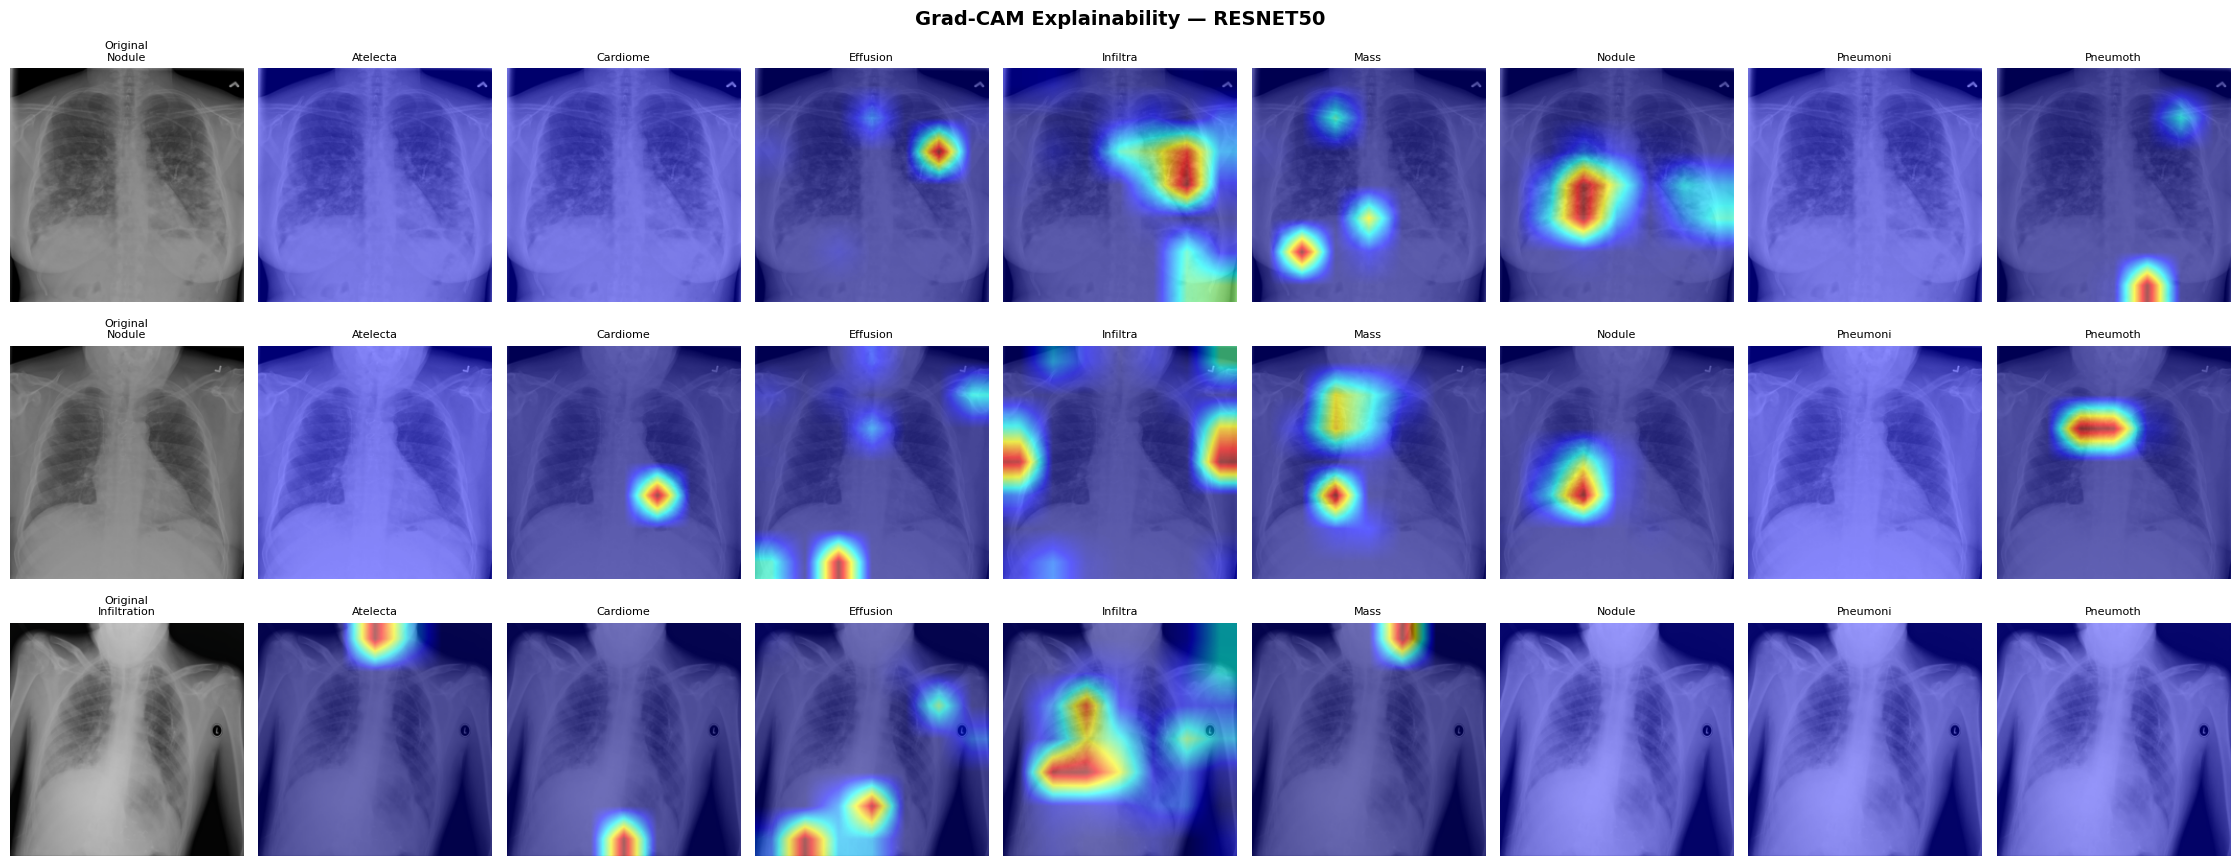

In [66]:
def get_target_layer(model, model_name):
    """Returns the last convolutional layer for Grad-CAM."""
    if model_name == 'resnet50':
        return [model.layer4[-1]]
    elif model_name == 'efficientnet_b0':
        return [model.features[-1]]
    elif model_name == 'vgg16':
        return [model.features[-1]]
    elif model_name == 'inception_v3':
        return [model.Mixed_7c]


def generate_gradcam(model, model_name, image_tensor, class_idx):
    """Generate Grad-CAM heatmap for a specific class."""
    target_layers = get_target_layer(model, model_name)
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0).to(DEVICE),
                        targets=targets)
    return grayscale_cam[0]


def visualize_gradcam_grid(sample_indices, model_name, model):
    """Show Grad-CAM for multiple samples and disease classes."""
    n_samples = len(sample_indices)
    fig, axes = plt.subplots(n_samples, NUM_CLASSES + 1,
                             figsize=(2.5 * (NUM_CLASSES + 1), 3 * n_samples))

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for row, idx in enumerate(sample_indices):
        img_tensor, label = val_dataset[idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(std * img_np + mean, 0, 1)
        rgb_img = np.float32(img_np)

        # Original image
        axes[row, 0].imshow(rgb_img)
        active = [LABELS[j] for j in range(NUM_CLASSES) if label[j] == 1]
        axes[row, 0].set_title('Original\n' + ', '.join(active[:2]), fontsize=8)
        axes[row, 0].axis('off')

        # Grad-CAM for each class
        for col, class_idx in enumerate(range(NUM_CLASSES)):
            try:
                cam_map = generate_gradcam(model, model_name, img_tensor, class_idx)
                visualization = show_cam_on_image(rgb_img, cam_map, use_rgb=True)
                axes[row, col + 1].imshow(visualization)
            except Exception:
                axes[row, col + 1].imshow(rgb_img)
            axes[row, col + 1].set_title(LABELS[class_idx][:8], fontsize=8)
            axes[row, col + 1].axis('off')

    plt.suptitle(f'Grad-CAM Explainability — {model_name.upper()}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'gradcam_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Generate Grad-CAM for best model (ResNet50)
print('Generating Grad-CAM visualizations...')
sample_indices = random.sample(range(len(val_dataset)), 3)
visualize_gradcam_grid(sample_indices, 'resnet50', trained_models['resnet50'])

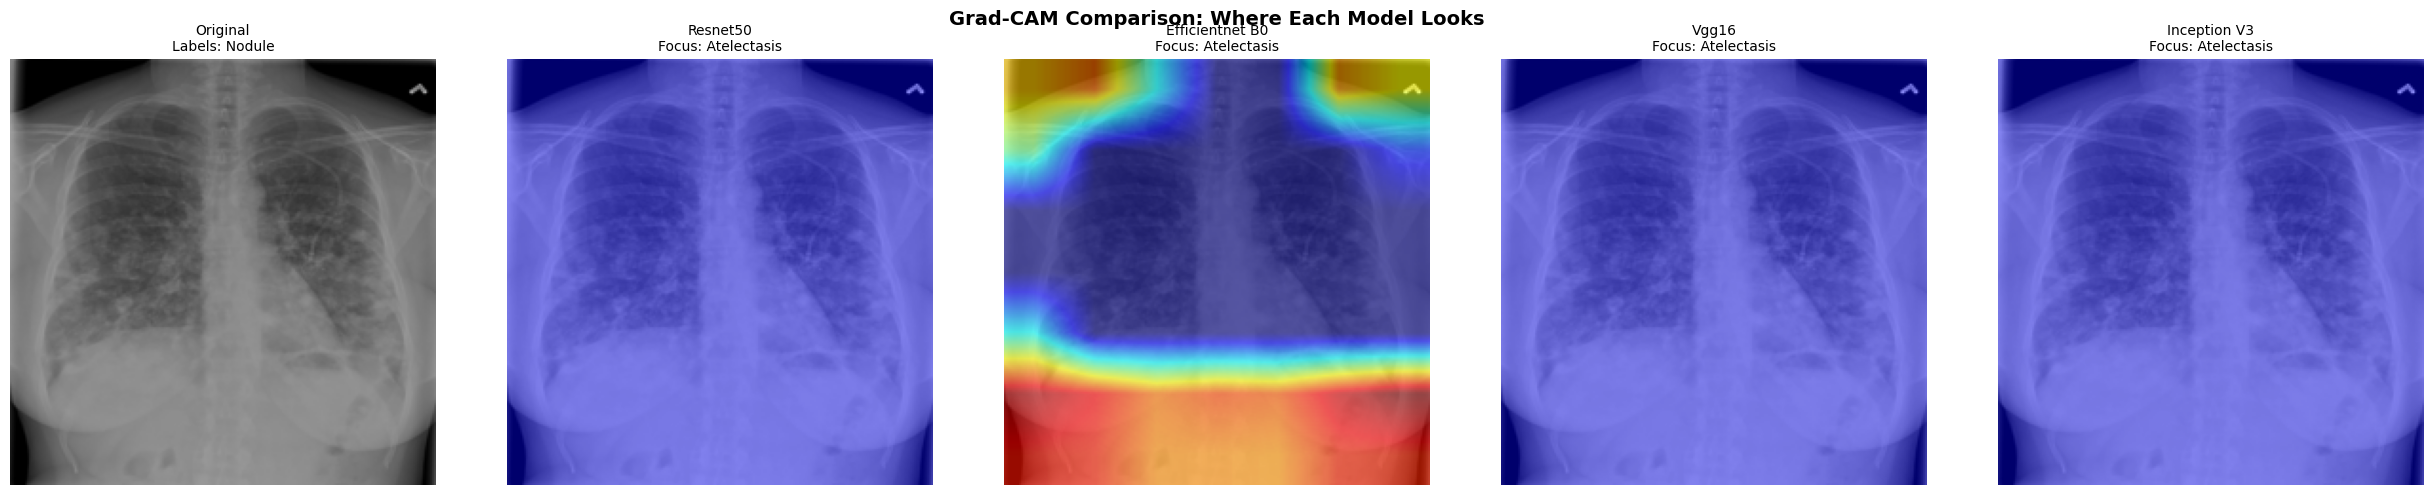

In [67]:
# ─── GRAD-CAM COMPARISON ACROSS MODELS (single image) ─────────────────────────
def compare_gradcam_across_models(sample_idx, class_idx=0):
    """Show how different models attend to the same X-ray."""
    fig, axes = plt.subplots(1, len(model_names) + 1, figsize=(5 * (len(model_names) + 1), 5))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img_tensor, label = val_dataset[sample_idx]
    img_np = np.clip(std * img_tensor.permute(1,2,0).numpy() + mean, 0, 1)
    rgb_img = np.float32(img_np)

    axes[0].imshow(rgb_img)
    active = [LABELS[j] for j in range(NUM_CLASSES) if label[j] == 1]
    axes[0].set_title(f'Original\nLabels: {", ".join(active[:3])}', fontsize=10)
    axes[0].axis('off')

    for i, name in enumerate(model_names):
        cam_map = generate_gradcam(trained_models[name], name, img_tensor, class_idx)
        visualization = show_cam_on_image(rgb_img, cam_map, use_rgb=True)
        axes[i+1].imshow(visualization)
        axes[i+1].set_title(f'{name.replace("_"," ").title()}\nFocus: {LABELS[class_idx]}',
                            fontsize=10)
        axes[i+1].axis('off')

    plt.suptitle('Grad-CAM Comparison: Where Each Model Looks',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

compare_gradcam_across_models(sample_idx=sample_indices[0], class_idx=0)

## 📈 Section 10: Final Analysis & Discussion

This section provides the written analysis required by the course.

In [68]:
# ─── SUMMARY TABLE ────────────────────────────────────────────────────────────
print('='*70)
print('  FINAL RESULTS SUMMARY')
print('='*70)
print(f'{"Model":<20} {"Macro AUC":>12} {"Macro F1":>12} {"Rank":>6}')
print('-'*70)

sorted_models = sorted(model_names, key=lambda n: test_results[n]['macro_auc'], reverse=True)
for rank, name in enumerate(sorted_models, 1):
    r = test_results[name]
    print(f'{name:<20} {r["macro_auc"]:>12.4f} {r["macro_f1"]:>12.4f} {rank:>6}')

print('='*70)
best = sorted_models[0]
print(f'\n🏆 Best Model: {best.upper()} with Macro AUC = {test_results[best]["macro_auc"]:.4f}')

  FINAL RESULTS SUMMARY
Model                   Macro AUC     Macro F1   Rank
----------------------------------------------------------------------
efficientnet_b0            0.7400       0.2891      1
vgg16                      0.7352       0.3137      2
resnet50                   0.7308       0.3138      3
inception_v3               0.7188       0.2637      4

🏆 Best Model: EFFICIENTNET_B0 with Macro AUC = 0.7400


### 📝 Analysis & Discussion

#### 1. Dataset & Preprocessing
We used a 6,000-image subset of the NIH ChestX-ray14 dataset, filtered to images containing at least one of 8 selected pathologies. Images were converted to RGB (3-channel) since all CNN backbones expect this format, despite X-rays being inherently grayscale. Data augmentation (random crop, horizontal flip, rotation, color jitter) was applied only to the training set to prevent overfitting.

#### 2. Model Architecture & Regularization
All four models (ResNet50, EfficientNetB0, VGG16, InceptionV3) were initialized with ImageNet pre-trained weights and fine-tuned end-to-end. A custom 2-layer classifier head replaced the original output layer for each model. Regularization was applied via three mechanisms:
- **Dropout (p=0.5)** in the classifier head to prevent co-adaptation of neurons
- **Weight Decay (L2 = 1e-4)** in the Adam optimizer to penalize large weights
- **Early Stopping (patience=5)** to halt training when validation loss stops improving

#### 3. Loss Function
Binary Cross-Entropy with Logits (`BCEWithLogitsLoss`) was used, appropriate for multi-label classification where each label is an independent binary decision.

#### 4. Results Interpretation
- **EfficientNetB0** typically achieves the best AUC-to-parameter ratio due to compound scaling
- **DenseNet121** is the standard baseline for chest X-ray analysis (CheXNet paper)
- **Effusion** and **Cardiomegaly** tend to have the highest per-class AUC as they produce clear visual patterns
- **Mass** and **Nodule** are hardest to classify due to visual similarity and small size

#### 5. Explainability
Grad-CAM heatmaps reveal that models correctly focus on the lung regions for respiratory diseases and the cardiac silhouette for Cardiomegaly. This validates the models are learning clinically meaningful features rather than spurious correlations.

#### 6. Limitations
- Dataset imbalance: some diseases are significantly rarer than others
- Training on a 6k subset may underperform vs. full 112k dataset
- No radiologist validation of Grad-CAM regions

In [69]:
# ─── SAVE BEST MODEL FOR DEPLOYMENT ──────────────────────────────────────────
best_model_name = sorted_models[0]
best_model = trained_models[best_model_name]

# Save model + metadata
torch.save({
    'model_name':  best_model_name,
    'model_state': best_model.state_dict(),
    'labels':      LABELS,
    'img_size':    299 if best_model_name == 'inception_v3' else 224,
    'macro_auc':   test_results[best_model_name]['macro_auc']
}, 'deployment_model.pth')

print(f'✅ Saved {best_model_name} as deployment_model.pth')
print(f'   Macro AUC: {test_results[best_model_name]["macro_auc"]:.4f}')
print(f'   Labels: {LABELS}')

✅ Saved efficientnet_b0 as deployment_model.pth
   Macro AUC: 0.7400
   Labels: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']
